### 径向柱状图与普通柱状图类似，都是以柱形高度来表示数值大小。区别在于，该图的柱形是沿着极坐标的径向延伸的。
### 该图特别适合表达周期性的数据，例如数据在一天内的变化，或数据在多个方向上的分布等。
### 适合表示某个特征随着某个变化而变化的变化趋势，替换线条图，y随着x的变化而变化。

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [2]:
# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

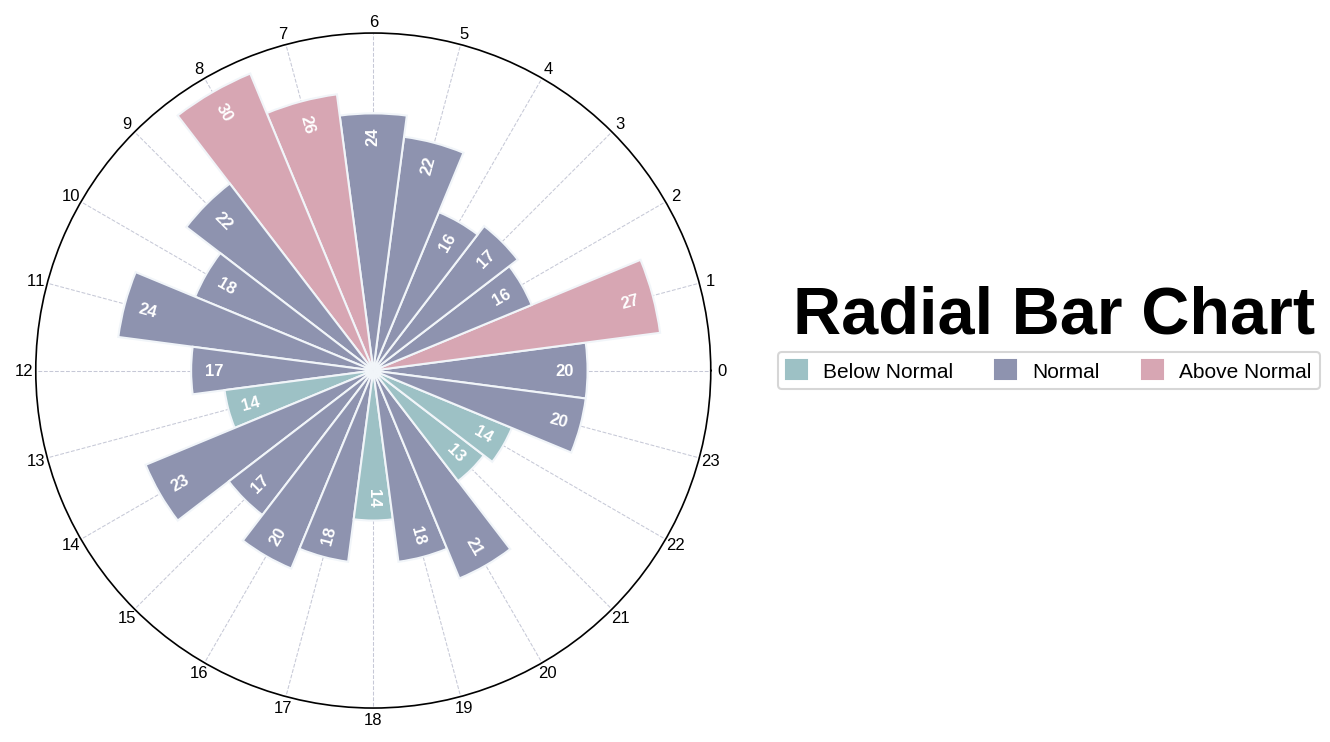

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # Added missing import for legend patches

# ------------------------------------------------------------------------------
# Data Preparation
# ------------------------------------------------------------------------------
values = [20, 27, 16, 17, 16, 22, 24, 26, 30, 22, 18, 24, 
          17, 14, 23, 17, 20, 18, 14, 18, 21, 13, 14, 20]
count = len(values)
angles = np.linspace(0, 2 * np.pi, count, endpoint=False)  # Angles for each bar
xticks = np.arange(count)

# ------------------------------------------------------------------------------
# Create Polar Plot
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), 
                       subplot_kw={"projection": "polar"}, dpi=150)

# Define colors based on value ranges
colors = []
for v in values:
    if v < 15:
        colors.append("#9dc1c5")  # Below normal
    elif v > 25:
        colors.append("#d7a6b3")  # Above normal
    else:
        colors.append("#8e93af")  # Normal

# Plot radial bars
bars = ax.bar(
    angles,
    values,
    width=2 * np.pi / count,
    bottom=10,  # Base height for all bars
    color=colors,
    edgecolor="#f1f5f9",
    linewidth=1,
    zorder=2
)

# Add data labels on top of bars
for bar, angle, value in zip(bars, angles, values):
    rotation = np.degrees(angle)  # Convert radians to degrees for text rotation
    # Adjust horizontal alignment to avoid upside-down text
    ha = "right" if 90 < rotation < 270 else "left"
    # Rotate text to match bar orientation (fix upside-down labels)
    rotation = rotation - 180 if 90 < rotation < 270 else rotation
    
    ax.text(
        angle,
        value + 7,  # Vertical offset from bar top
        f"{int(value)}",  # Display value as integer
        ha=ha,
        va="center",
        fontsize=8,
        fontweight="bold",
        rotation=rotation,
        rotation_mode="anchor",  # Align rotation with text anchor
        color="#ffffff",
        zorder=4,
    )

# ------------------------------------------------------------------------------
# Legend Configuration
# ------------------------------------------------------------------------------
low_handle = mpatches.Patch(color="#9dc1c5", label="Below Normal")
normal_handle = mpatches.Patch(color="#8e93af", label="Normal")
high_handle = mpatches.Patch(color="#d7a6b3", label="Above Normal")
handles = [low_handle, normal_handle, high_handle]

# Add legend to figure (not axis)
fig.legend(handles=handles, loc="center right", 
           handleheight=1, handlelength=1, ncols=3)

# ------------------------------------------------------------------------------
# Polar Grid Adjustments
# ------------------------------------------------------------------------------
ax.set_yticks([])  # Hide radial grid lines
ax.set_xticks(angles)  # Set angular grid positions
ax.set_xticklabels(xticks)  # Label angular grid with sequence numbers
ax.tick_params(axis="x", labelsize=8, pad=-5)  # Adjust x-tick label size and position

# ------------------------------------------------------------------------------
# Add Plot Title
# ------------------------------------------------------------------------------
fig.text(x=0.68, y=0.55, s="Radial Bar Chart", 
         fontdict={"size": 32, "weight": "bold"})

# ------------------------------------------------------------------------------
# Grid Style
# ------------------------------------------------------------------------------
ax.grid(axis="x", linestyle="--", linewidth=0.5, 
        color="#8e93af", alpha=.5, zorder=1)

# ------------------------------------------------------------------------------
# Layout Optimization
# ------------------------------------------------------------------------------
plt.tight_layout()
# Adjust subplot margins to fit legend and title
plt.subplots_adjust(left=0, right=0.66, top=0.95, bottom=0.05)
# plt.savefig('./Fig.pdf', dpi=300, bbox_inches='tight')
plt.show()